Imports

In [1]:

import matplotlib.pyplot as plt

from Background_functions import read_audio_file, split_audio_segments, start_end_times
from STFT import short_time_calc, plot_spectrogram
from DFT import dtw_calc

from pathlib import Path

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\DataSubmission\2023_04_22")

Data download

In [2]:
audio = DATA_22 / "20230422_171301.WAV"
f_s, x = read_audio_file(audio)

Template

In [10]:
text = DATA_22 / "20230422_171301.Detections.selections.txt"
temp_marks, start_t_temp, end_t_temp = start_end_times(text)

whale_call_segments = split_audio_segments(x, f_s, start_t_temp, end_t_temp)
num_temps =len(whale_call_segments)
print(f"Number of calls in given file: {num_temps}")
audio_template_1 = whale_call_segments[14]

Number of calls in given file: 628


Running loop for STFT template analysis

In [22]:
stft_cost = []
oor = []
low = 0.0
high = 0.00
in_range = 0
tot_calls = 259 
while in_range < tot_calls:
    oor = []
    i = 0
    high = round(high + 0.01, 2)
    for i in range(num_temps):
        audio_seg = whale_call_segments[i]
        f_temp, t_temp, Zxx_temp, fs_new = short_time_calc(audio_template_1, f_s)
        f_seg, t_seg, Zxx_seg, fs_new = short_time_calc(audio_seg, f_s)
        dtw_cost = dtw_calc(Zxx_temp, Zxx_seg)
        stft_cost.append(dtw_cost)

        if low < dtw_cost < high:
            oor.append(i)
    in_range = len(oor)

print(f"Number of calls for {low} < dtw_cost < {high}: {in_range}")

Number of calls for 0.0 < dtw_cost < 0.07: 282


Spectogoram of Template:


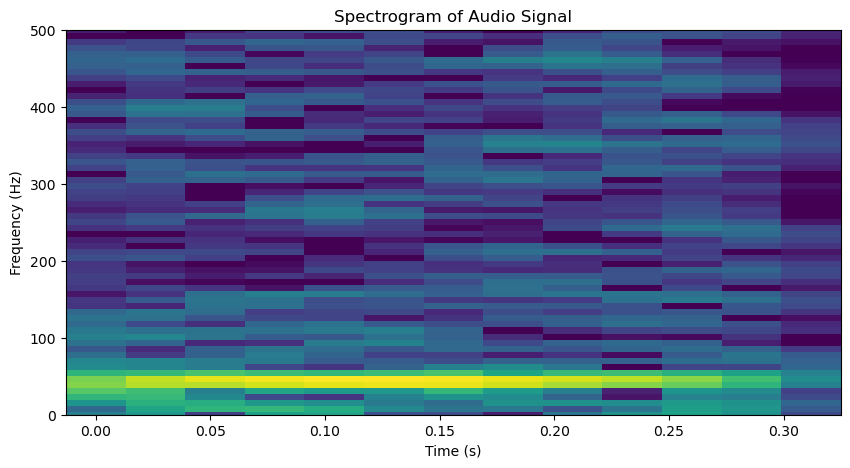

Spectogoram of Matches:


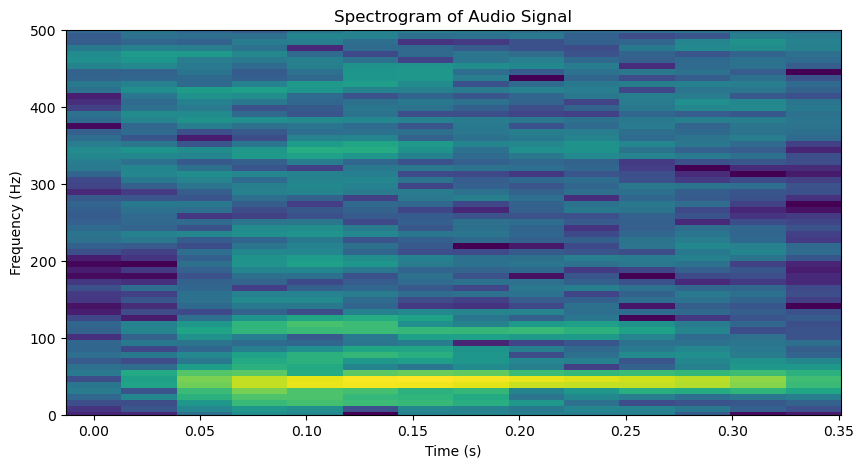

dtw cost: 0.06325202623286288
index in templates:  0
start_t: 51713.5319375


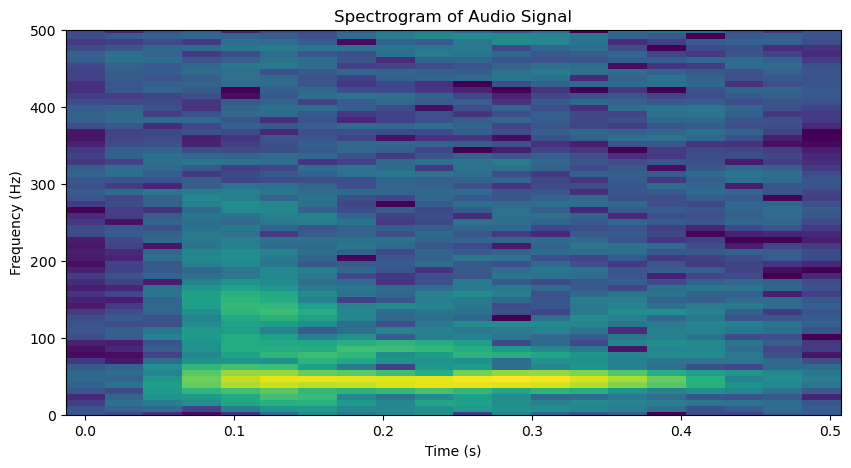

dtw cost: 0.06531548002256264
index in templates:  1
start_t: 68032.2519375


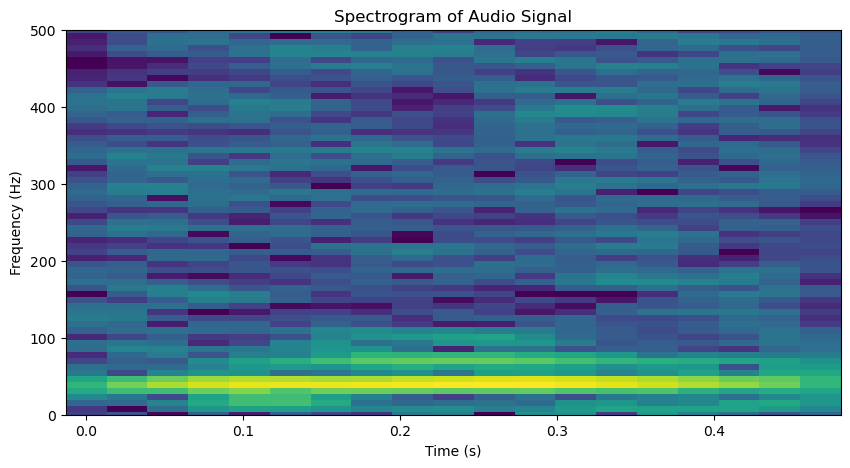

dtw cost: 0.0538600675126267
index in templates:  6
start_t: 76653.0199375


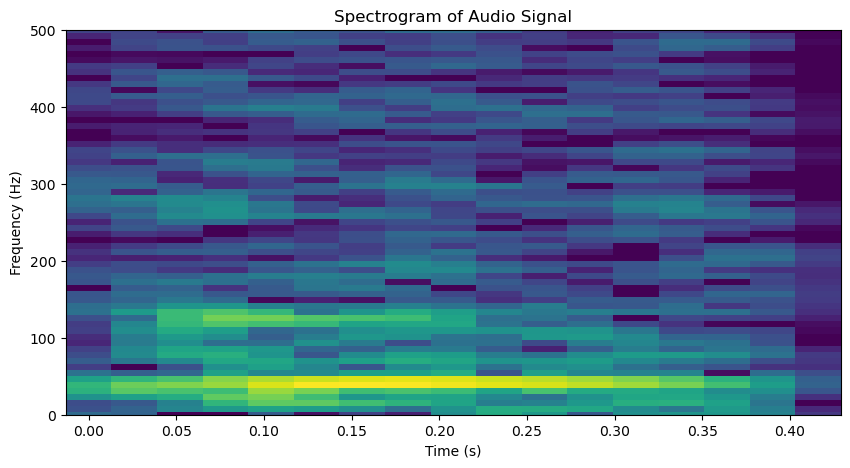

dtw cost: 0.05564077189713501
index in templates:  11
start_t: 134626.1079375


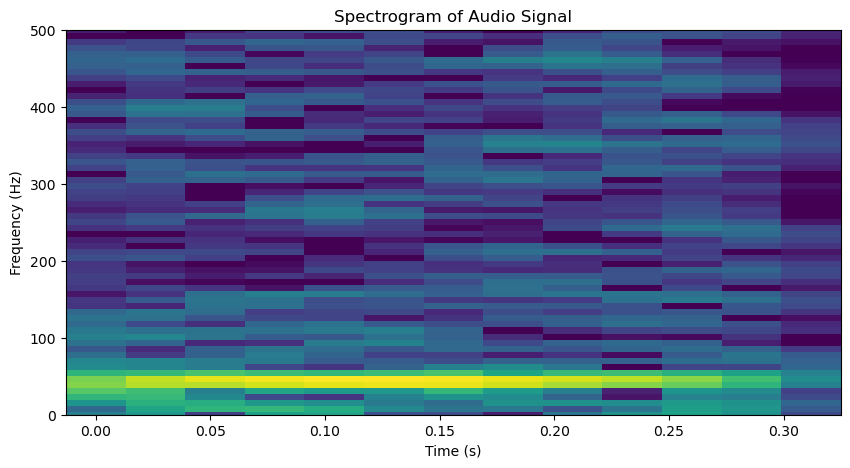

dtw cost: 8.540177112501205e-18
index in templates:  14
start_t: 134912.18793749998


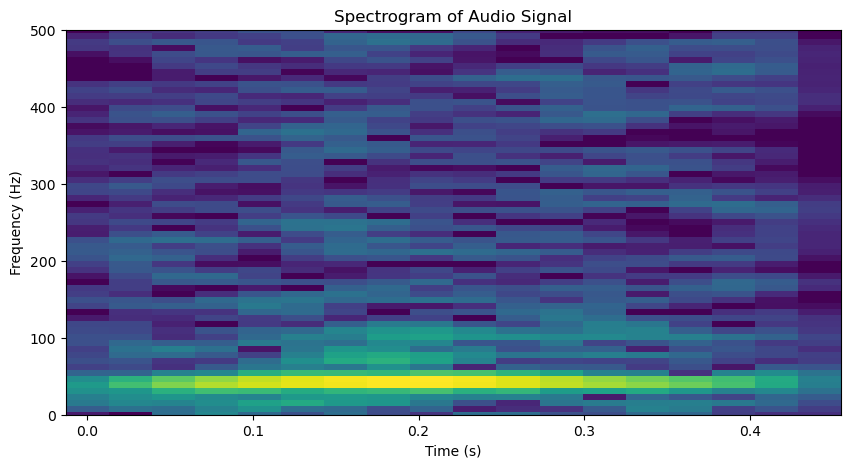

dtw cost: 0.036268630099202136
index in templates:  17
start_t: 143045.0839375


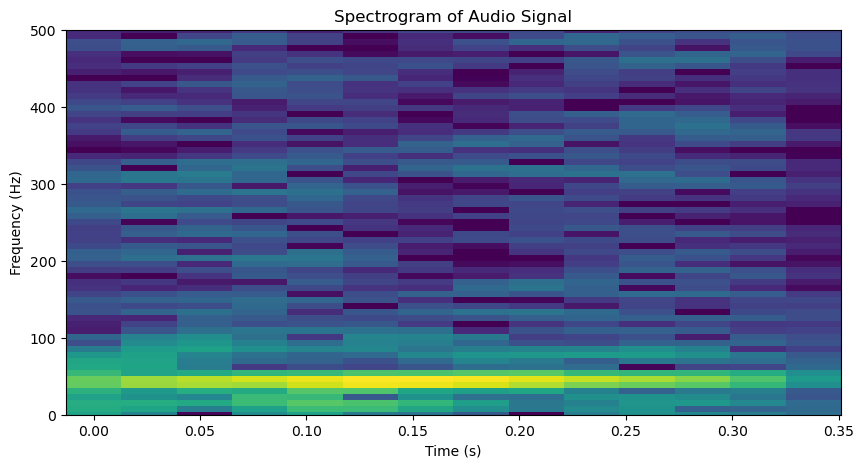

dtw cost: 0.02064931173174925
index in templates:  20
start_t: 146669.2119375


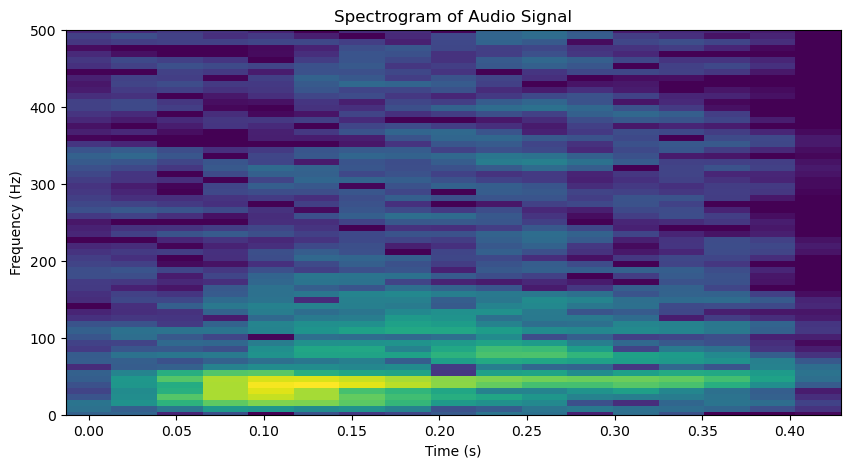

dtw cost: 0.06856605873856807
index in templates:  21
start_t: 146754.2679375


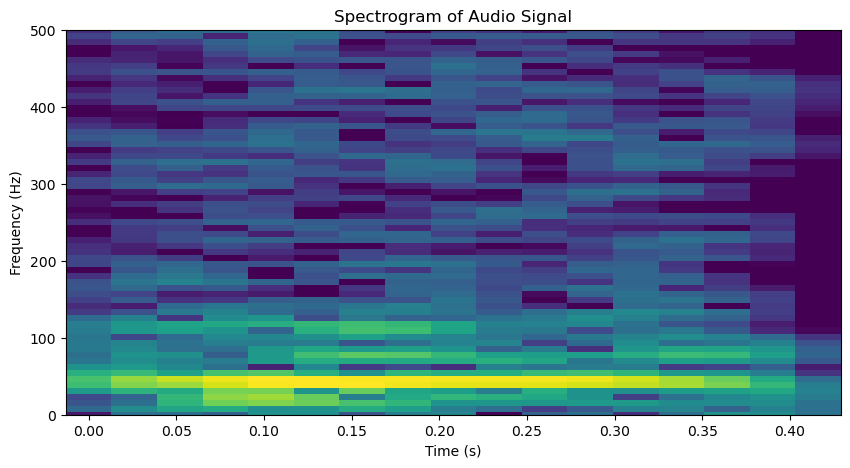

dtw cost: 0.037045731043901534
index in templates:  23
start_t: 146870.3959375


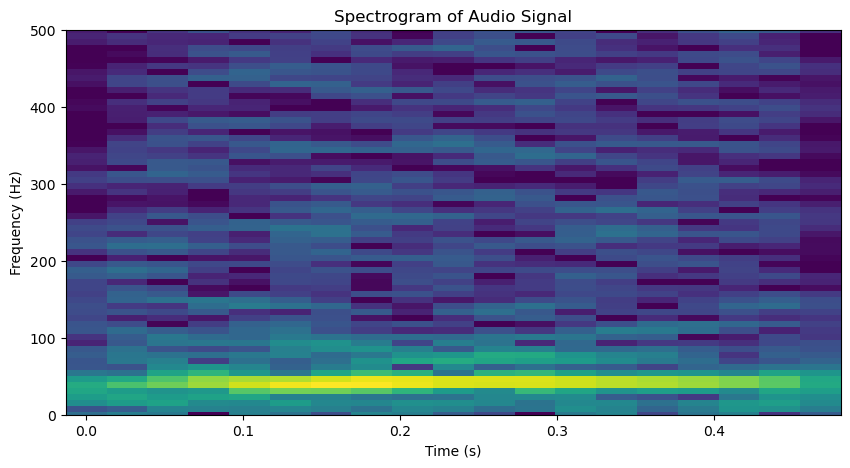

dtw cost: 0.03241979388401568
index in templates:  24
start_t: 147054.9079375


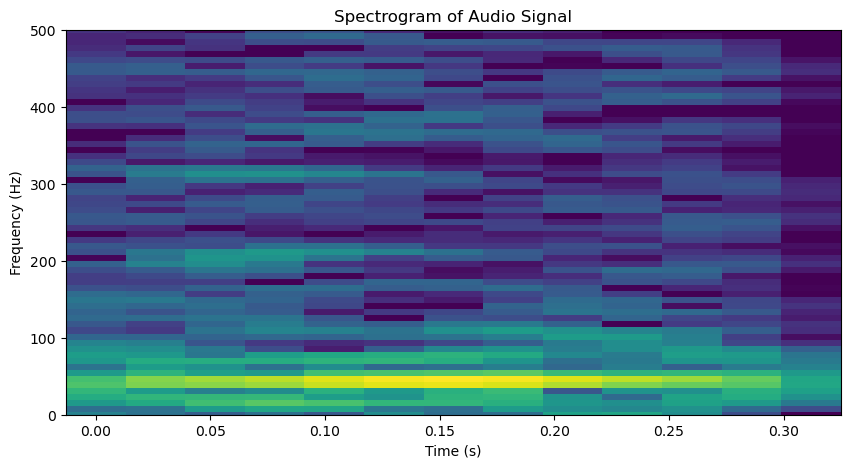

dtw cost: 0.029261302518367706
index in templates:  26
start_t: 147145.46793749998


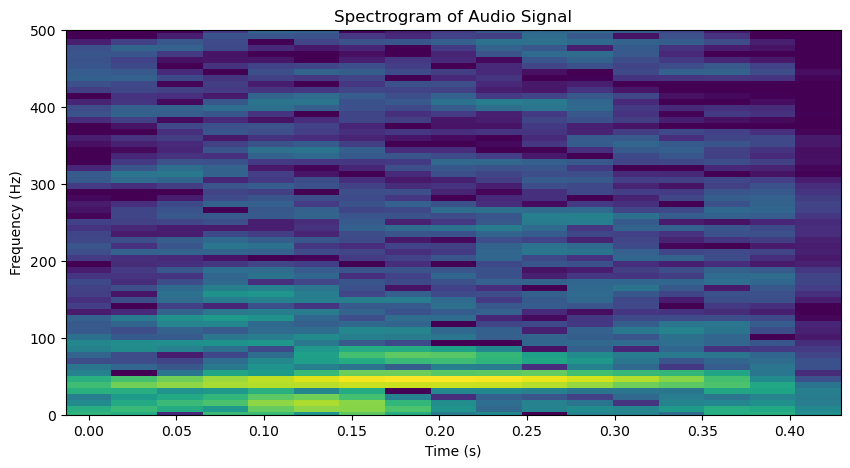

dtw cost: 0.0462332039307891
index in templates:  28
start_t: 147218.2999375


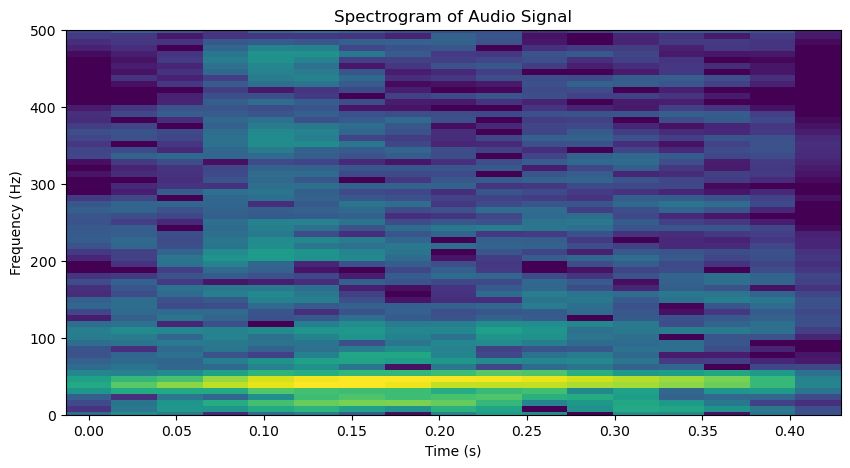

dtw cost: 0.03161632907036538
index in templates:  29
start_t: 147440.89193749998


In [13]:
print("Spectogoram of Template:")
plot_spectrogram(f_temp, t_temp, Zxx_temp, fs_new)
print("Spectogoram of Matches:")
for j in range(13):
    f_sig, t_sig, Zxx_sig, fs_new = short_time_calc(whale_call_segments[oor[j]], f_s)
    plot_spectrogram(f_sig, t_sig, Zxx_sig, fs_new)
    plt.show()
    print(f"dtw cost: {stft_cost[oor[j]]}")
    print(f"index in templates: {oor[j]: .0f}")
    print(f"start_t: {start_t_temp[oor[j]]}")
